# Matter Power Spectrum

In this notebook we are going to generate a matter density field, reproducing the distribution of matter on large scales in the Universe.

We will play with the CAMB matter power spectrum and see the impact of cosmological parameters. 


Some parts of the notebook are from Oliver Hahn lecture notes https://github.com/ohahn/LesHouches2025/blob/main/LSSfromGRF.ipynb, others are adapted from the 2025 IA school notebooks. 
    

# 1. Gaussian Random fields


A lot of observables in cosmology can be described with a Gaussian random field (GRF). A GRF $f$ is defined as a set of random variables, parametrized over a domain $\mathcal{D} \subset \mathbb{R}^4$ such that for a finite set of points $\mathbf{x}_0, ... \mathbf{x}_{n} \in \mathcal{D}$, the random variables $f(\mathbf{x}_1), ... f(\mathbf{x}_n)$ are jointly Gaussian distributed. This joint distribution is fully specified by the mean vector $\mathbf{\mu}(\mathbf{x}_i)$ and the covariance matrix $(C)_{ij} = C(\mathbf{x}_i , \mathbf{x}_j)$
i.e.
$$
\mathbb{E}[f(\mathbf{x}_i)] = \mathbf{\mu}(\mathbf{x}_i)\, , 
$$
$$
\mathbb{E}\left[f(\mathbf{x}_i) f(\mathbf{x}_j)\right] = C(\mathbf{x}_i , \mathbf{x}_j) + \mathbf{\mu}(\mathbf{x}_i) \mathbf{\mu}(\mathbf{x}_i) \, .
$$

A field is centered if $\mu(\mathcal{x})=0, \, \forall \, x$. In the following we will work with centered field, as in practice we can simply re-define the field with $f-\mu$.  


A field is called **homogeneous** if the covariance is translation-invariant, i.e. if a function $\mathcal{C}$ exists so that
$$
C(\mathbf{x}_i , \mathbf{x}_j  ) = \mathcal{C}(\mathbf{x}_i − \mathbf{x}_ j ) \, .
$$

This function $ \mathcal{C}(\mathbf{r})$ is called the two point correlation function. 


A field is called **isotropic** if the covariance is rotation-invariant, i.e. if a function $\xi$ exists so that
$$
C(\mathbf{x}_i , \mathbf{x}_j  ) = \mathcal{\xi}(\left||\mathbf{x}_i − \mathbf{x}_ j \right||) 
$$
Note that if a field is isotropic in every point, then it is homogeneous. 



### Uncorrealted (white noise) GRF


A white Gaussian random field with no correlations has a normal distribution at every point, and the covariance between any two points is given by:
$$ C(\mathbf{x}, \mathbf{y}) = \sigma^2 \delta(\mathbf{x}- \mathbf{y})$$

where $\sigma$ is the variance of the field and $\delta$ is the Dirac delta function. This means that the values of the field at different points are independent (we also say uncorrelated) 



    

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib import colors

In [2]:
N = 128 # number of pixels in our map 

In [3]:
# create a Gaussian random field of size N**2
sigma2 = 1.0
delta0 = np.random.normal(size=[N,N]) * np.sqrt(sigma2)


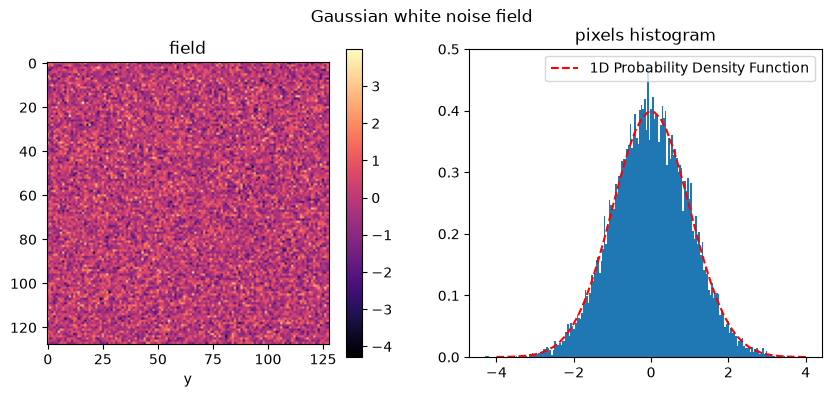

In [4]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
fig.suptitle('Gaussian white noise field')
im = ax[0].imshow(delta0, cmap='magma')
fig.colorbar(im, ax=ax[0])

ax[1].hist(delta0.flatten(),bins=200,density=True);

xx = np.linspace(-4*np.sqrt(sigma2), 4*np.sqrt(sigma2))
ax[1].plot(xx, 1/np.sqrt(2*np.pi*sigma2) * np.exp(-xx**2 / 2 / sigma2), ls='--', color='red',  label='1D Probability Density Function')


ax[0].set_xlabel('x')
ax[0].set_xlabel('y')
ax[0].set_title('field')


ax[1].set_title('pixels histogram')
ax[1].legend()

### Power spectrum

The Fourier transform (FT) of a GRF is also a GRF. 
If the field is homogeneous and centered, then its covariance in Fourier space is diagonal with
$$ 
\mathbb{E}[ f(\mathbf{k})f^*(\mathbf{k}')] = (2π)^d δ_D(\mathbf{k} − \mathbf{k}')P (\mathbf{k}) \, ,
$$

where δ_D is the Dirac-δ distribution, and $P(\mathbf{k})$ is the **power spectrum**, defined as the Fourier transform of the covariance function

$$
P (\mathbf{k}) := \int_{\mathbb{R}^d} d^d r \exp^{-i \mathbf{k}\cdot \mathbf{r}} \mathcal{C}(\mathbf{r}) 
$$

If the GRF is isotropic, its power spectrum is also isotropic, such that 
$P(\mathbf{k})= P(\left|| \mathbf{k} \right||) $, and we often simply write $P(k)$. 

We can therefore generate a centered homogeneous and isotropic GRF by sampling in the diagonal Fourier eigenbasis.




# 2. Matter power spectrum 

Our goal now is to simulate a cosmological field. For this we first need to compute a prediction of the matter power spectrum $P(k)$. We will then sample a GRF from this matter power spectrum. 
Codes that allows us to predict cosmological power spectra are called *Boltzmann solvers*, because they allow to solve numerically the Boltzmann equations that computes the perturbations of cosmological particles (photons, dark matter, baryons and neutrinos).

CAMB is a cosmology library that allows to predict several cosmological observables. It takes as input a cosmological model and cosmological parameter values. 
We will assume the LCDM model, and the default comsological parmaeter values from CAMB.


In [5]:
import camb

In [6]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)


redshifts = [0] # List of redshifts at whihc we want ot compute the matter power spectrum 
pars.set_matter_power(redshifts=redshifts, kmax=20)

#Linear spectra
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
kh, zs, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=400)
P_k = pk[0]

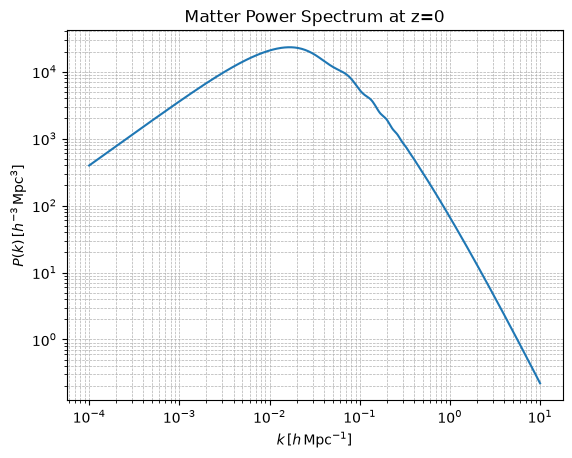

In [7]:
# Plot the power spectrum
fig, ax = plt.subplots()
ax.loglog(kh, P_k, label='Power Spectrum (z=0)')
ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')
ax.set_title(f'Matter Power Spectrum at z={redshifts[0]}')
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

#### 🧩 Exercise: Plot the power spectrum for different redshifts 


Note: redshifts have been re-sorted (earliest first)


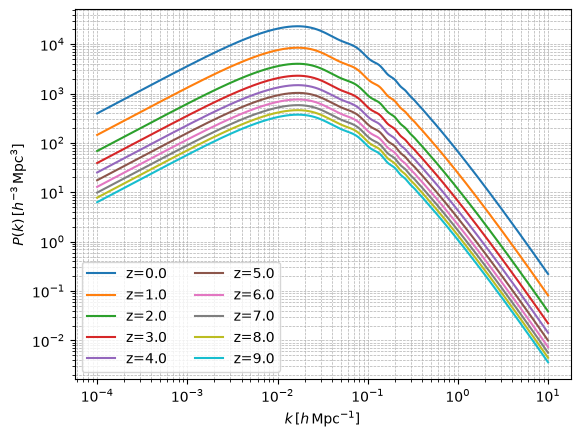

In [8]:
redshifts = np.arange(10)
pars.set_matter_power(redshifts=redshifts, kmax=20)
results = camb.get_results(pars)
kh, zs, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=400)

fig, ax = plt.subplots()

for z, P_k in zip(zs, pk):
    ax.loglog(kh, P_k, label=f'z={z}')

ax.legend(ncol=2)
ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# 3. Friedmann equation: density parameters

The **Friedmann equation** gives us a closure relation for the density parameters of all the components of the Universe. 

$$
H^2(z) = H_0^2 \left[ \Omega_{\mathrm{rad}}(1+z)^4 + \Omega_{\mathrm{m}}(1+z)^3 + \Omega_{\mathrm{k}}(1+z)^2 + \Omega_{\Lambda} \right].
$$

Where $\Omega_{\rm m}$ is the matter density, $ \Omega_{\Lambda}$ is the dark energy density, $\Omega_{\rm rad}$ is the radiation density, and $\Omega_{\rm k}$ is the curvature density, all defined at $z=0$.  
Thus at $z=0$ we have $$1 = \Omega_{\mathrm{rad}} + \Omega_{\mathrm{m}}+ \Omega_{\mathrm{k}}+ \Omega_{\Lambda} $$

**Matter**

In the $\Lambda$CDM model, the matter is composed of two species: cold dark matter and baryons (which contains all of ordinary matter). We thus have $\Omega_m = \Omega_{\rm cdm} + \Omega_{\rm baryon}$, where $\Omega_{\rm cdm}$ is the cold dark matter density, $\Omega_{\rm baryon}$ is the baryon matter density.

In the following, we will fix the baryon density which is measured very well from the Big Bang Nucleosynthesis, i.e. the number of premordial Hydrogen and Helium atoms generated at teh Big Bang, whihc gives a value of $\Omega_b h^2= 0.0224$.

**Radiation**

Radiation is composed of relativistic species, which in the standard $\Lambda$CDM are photons and massless neutrinos. The density of photons $\Omega_\gamma$ is obtained from the temperature of the Cosmic Microwave Background (CMB), $T_{\rm CMB} = 2.7255 \, \rm K$, which gives us $\Omega_\gamma h^2 \simeq 2.4728 \cdot 10^{−5}$
The density of relativistic (massless) neutrinos is related to the density of photons with $\Omega_\nu = \Omega_\gamma \frac78 \left(\frac{4}{11}\right)^{4/3} N_{\rm eff}$, where $N_{\rm eff}$ is the effective number of relativistic species. There are 3 species of neutrinos, but due to some correction from the physics of neutrinos at the moment of decoupling, we get $N_{\rm eff} = 3.044$. 

Thus we have $$\Omega_{\rm rad} = \Omega_\gamma \left( 1 + \frac78 \left(\frac{4}{11}\right)^{4/3} N_{\rm eff} \right)\, .$$ 


#### 🧩 Exercise: vary $\Omega_m$
For a flat universe $\left(\Omega_k=0\right)$, vary $\Omega_m$ from $\Omega_m=0.1$ up to a Universe without dark energy $\left(\Omega_\Lambda = 0\right)$ (often called Einstein de Sitter Universe).

CAMB uses physical density parameters, which are defined by 
$ \omega_i = \Omega_i h^2$, 
where $h = \frac{H_0 }{ \left( 100 \, \rm km/Mpc/s\right)}$

Tips: 
- you can check that the Friedmann equation is validated after running CAMB, with the function `results.get_Omega()`
- if using the radiation density as defined above, keep in mind this works for massless neutrinos only 



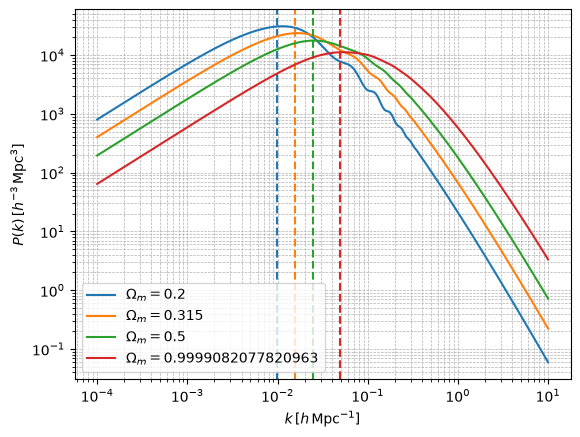

In [9]:
# Fixed quantities 

H0 = 67.5 # km/s/Mpc
h = H0 / 100 # Reduced Hubble parmater (dimensionless) 
h2 = (H0 / 100)**2

# Density parameters 
ombh2 = 0.0224
omgh2 = 2.4728 * 1e-5 
Neff = 3.044
omrh2 = omgh2 * (1 + 7/8 * (4/11)**(4/3) * Neff) # For massless neutrinos 
omk = 0

# We assume massless neutrinos
mnu=0
num_massive_neutrinos=0

# Set up the range of Omega Matter we want to sample 
Omega_m_array = np.array([0.2, 0.315, 0.5, 1 - omrh2/h2])

def k_eq_hmpc(Om):
    # Scale of radiation matter equality 
    return 7.3 * 1e-2 * Om * h2 / h  # [h/Mpc]

fig, ax = plt.subplots()

for Om in Omega_m_array: 
    
    omch2 = Om * h2 - ombh2
    
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=omk, tau=0.06, num_massive_neutrinos=num_massive_neutrinos)
    pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
    pars.set_matter_power(redshifts=[0], kmax=100.0)
    
    #Linear spectra
    pars.NonLinear = camb.model.NonLinear_none
    results = camb.get_results(pars)
    
    kh, zs, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=400)
    P_k = pk[0]

    # Plot the power spectrum
    p = ax.loglog(kh, P_k, label=rf'$\Omega_m = {Om}$')
    ax.axvline(k_eq_hmpc(Om), c=p[0].get_color(), ls='--')

ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend()

In [10]:
for val in ['cdm', 'baryon', 'photon', 'neutrino', 'de', 'K' ]:
    print(f'Ω {val}: {results.get_Omega(val):.2e}')

Ω cdm: 9.51e-01
Ω baryon: 4.92e-02
Ω photon: 5.43e-05
Ω neutrino: 3.75e-05
Ω de: -6.51e-09
Ω K: 0.00e+00


In [11]:
results.get_Omega('cdm') + results.get_Omega('baryon') + results.get_Omega('neutrino') + results.get_Omega('photon')

np.float64(1.0000000065083032)

#### What changes when we vary $\Omega_m$

By varying $\Omega_m$ (while keeping $h$, $\Omega_b$, etc. fixed), we change the **epoch of matter–radiation equality**. The characteristic scale is
$$
k_{\rm eq} \equiv \frac{a_{\rm eq} H(a_{\rm eq})}{c}
\simeq 7.3\times 10^{-2}(\Omega_m h^2)\ {\rm Mpc}^{-1},
$$
with $a_{\rm eq}=\Omega_r/\Omega_m$.

Physically:

* for $k\ll k_{\rm eq}$, i.e. large scale modes which are **outside the horizon** at equality: the two particles are too far to interact, only gravity works, attract the matter and increase the inhomogeneities in density. The amplityde if the matter power spectrum goes up with time, following the slope of the primordial power spectrum at the end of inflation $P(k)\propto k^{n_s}$, with $n_s\simeq 1$;
* for $k\gg k_{\rm eq}$, i.e. small scale modes which are **inside the horizon** during radiation domination: Radiation pressure fights against gravity, and the baryon-photon fluid enters into oscillations of compression-decompression, which are called baryonic acoustic oscillations. The perturbations in density are not growing, the amplitude of the matter power spectrum is frozen in time.

Increasing $\Omega_m h^2$ **increases $k_{\rm eq}$** (equality occurs earlier) and shifts the *turnover* of $P(k)$ to **larger $k$**.

The scale $k_{\rm eq}$ acts as a **pivot scale** for the shape of the spectrum: changes in $\Omega_m$ make the $P(k)$ curves **“rotate”** around $k_{\rm eq}$ — below $k_{\rm eq}$, the variation is small (the tilt is nearly preserved), whereas above $k_{\rm eq}$, the suppression/enhancement changes significantly.


#### 🧩 On the previous plot, add a vertical line showing the matter-radiation equality scale


#### 🧩 If ahead of time, test impact of other parameters

For instance change the amplitude of primordial fluctuations As, the tilt of the initial power spectrum ns, the baryon density or the curvature density.

### Changing Omega_m

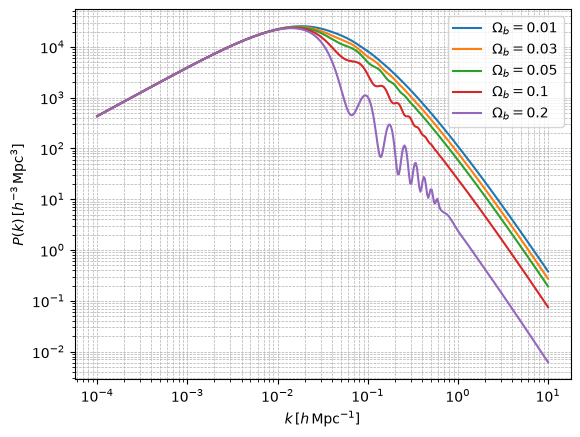

In [12]:
# Fixed quantities 

H0 = 67.5 # km/s/Mpc
h = H0 / 100 # Reduced Hubble parmater (dimensionless) 
h2 = (H0 / 100)**2

# Density parameters 
Omega_b_array = np.array([0.01, 0.03, 0.05, 0.1, 0.2])

# ombh2 = 
omgh2 = 2.4728 * 1e-5 
Neff = 3.044
omrh2 = omgh2 * (1 + 7/8 * (4/11)**(4/3) * Neff) # For massless neutrinos 
omk = 0

# We assume massless neutrinos
mnu=0
num_massive_neutrinos=0

Omega_m = 0.3

def k_eq_hmpc(Om):
    # Scale of radiation matter equality 
    return 7.3 * 1e-2 * Om * h2 / h  # [h/Mpc]

fig, ax = plt.subplots()

for Ob in Omega_b_array: 

    # ombh2 = Om * h2 - omch2
    # omch2 = Om * h2 - ombh2
    ombh2 = Ob*h2
    omch2 = Omega_m * h2 - ombh2
    
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=omk, tau=0.06, num_massive_neutrinos=num_massive_neutrinos)
    pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
    pars.set_matter_power(redshifts=[0], kmax=100.0)
    
    #Linear spectra
    pars.NonLinear = camb.model.NonLinear_none
    results = camb.get_results(pars)
    
    kh, zs, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=400)
    P_k = pk[0]

    # Plot the power spectrum
    p = ax.loglog(kh, P_k, label=rf'$\Omega_b = {Ob}$')

ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend()

# 4. Neutrinos 


We know from oscillations of neutrinos between three flavours, that they are massive, and have three mass states, but we dont know the value of their mass. We only measure the square of the mass difference between the different neutrino mass states.

When neutrinos are massive, their contribution to the energy budget on the Universe is $\Omega_\nu h^2 = \frac{\sum m_\nu}{93.14 \, \rm eV}$, where $\sum m_\nu$ is the sum of the mass of neutrinos. 


#### 🧩 Exercise: Compute and plot the power spectrum for different values of the neutrino mass. What is the impact?



Vary the sum of the neutrino mass from $\sum m_\nu = 0$ to $\sum m_\nu = 200 \, \rm meV$. We want to keep $\Omega_{\rm m}=0.315$ fixed to the fiducial, so that the scale of matter-radiation equality is fixed and we can isolate only the impact of chaging the neutrino mass. Pay attention that when neutrinos are massive they now count in the matter budget $\Omega_{\rm m}$, rather than in the radiation budget. 

We will assume all three species of neutrinos are massive, setting `num_massive_neutrinos=3`. 

Plot as well the ratio of the power spectrum with respect to the case with massless neutrinos, to better see the impact.

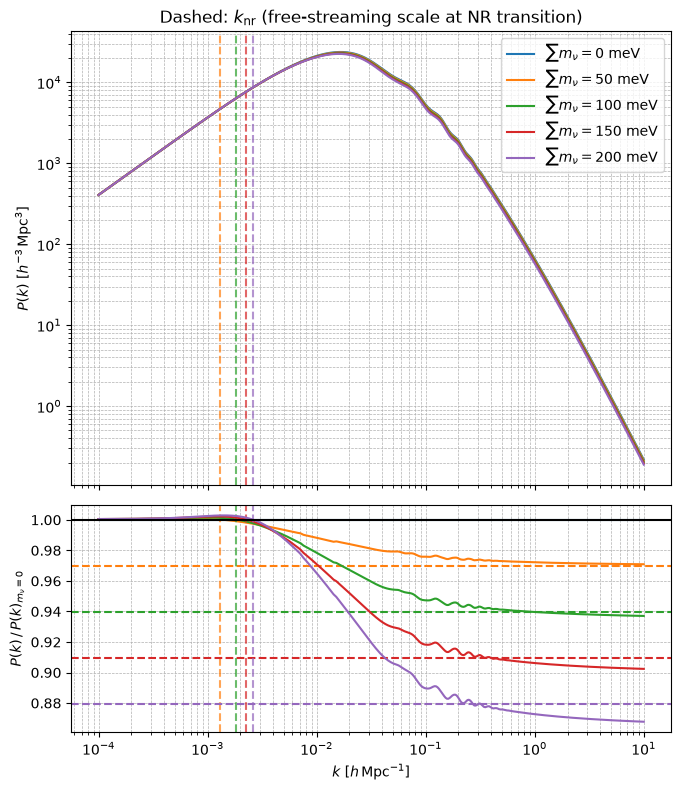

In [13]:
H0, h = 67.5, 0.675
ombh2 = 0.0224
omch2_ref = 0.120                      # reference CDM density
k = np.logspace(-4, 1, 400)            # h/Mpc
num_massive_neutrinos=3


# Sum of the mass of the three neutrinos 
mnu_array = np.array([0., 50., 100., 150., 200.]) * 1e-3   # eV

def get_pk(mnu):
    """Return kh [h/Mpc], P(k) at z=0, and Omega_m. Total omega_m held fixed."""
    omnuh2 = mnu / 93.14
    omch2 = omch2_ref - omnuh2
    pars = camb.CAMBparams()
    if mnu == 0:
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2,
                           mnu=0, num_massive_neutrinos=0, omk=0, tau=0.06)
    else:
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2,
                           mnu=mnu, num_massive_neutrinos=3,
                           neutrino_hierarchy='degenerate', omk=0, tau=0.06)
    pars.InitPower.set_params(As=2e-9, ns=0.965)
    pars.set_matter_power(redshifts=[0.], kmax=20.0)
    pars.NonLinear = camb.model.NonLinear_none
    results = camb.get_results(pars)
    kh, zs, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10,
                                                   npoints=400)
    om_m = (ombh2 + omch2 + omnuh2) / h2

    fnu = omnuh2/(om_m*h2)
    
    return kh, pk[0], om_m, fnu 


def k_nr(m_indiv, om_m):
    """Free-streaming scale at the non-relativistic transition [h/Mpc].
    m_indiv is the INDIVIDUAL eigenstate mass in eV."""
    return 0.018 * np.sqrt(om_m) * np.sqrt(m_indiv)


    
kh, P_ref, _, _ = get_pk(0.)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

for mnu in mnu_array:
    _, P, om_m, fnu = get_pk(mnu)
    lbl = rf'$\sum m_\nu = {mnu*1e3:.0f}$ meV'
    p = ax1.loglog(kh, P, label=lbl)
    ax2.semilogx(kh, P / P_ref, color=p[0].get_color(), label=lbl)

    if mnu > 0:
        knr = k_nr(mnu / 3., om_m)          # degenerate: m_i = sum / 3
        
        for a in (ax1, ax2):
            a.axvline(knr, color=p[0].get_color(), ls='--',  alpha=0.7)

        ax2.axhline(1-8*fnu, color=p[0].get_color(), ls='--')
        
ax2.axhline(1, c='k')
ax1.set_ylabel(r'$P(k)\ [h^{-3}\,\mathrm{Mpc}^3]$')
ax2.set_ylabel(r'$P(k)\,/\,P(k)_{m_\nu=0}$')
ax2.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax1.set_title(r'Dashed: $k_{\rm nr}$ (free-streaming scale at NR transition)')
for a in (ax1, ax2):
    a.grid(True, which='both', ls='--', lw=0.5)
ax1.legend()
plt.tight_layout()

#### What you should see 

The ratio plot is flat at 1 on large scales (small k's), then drops through a transition and flattens again at a suppressed plateau on small scales (large k's). For 200 meV the small-scale plateau lands around 0.85 — roughly 15% suppression.

**The physics**

Neutrinos escape out of the gravitational potential wells while relativistic (we say they free-stream). Below the free-streaming scale they don't cluster, so they contribute to the background expansion but not to the perturbation growth that sources it.
The free-streaming scale depends on the ratio of the expansion of the Universe over the velocity of neutrinos, and is given by $k_{\rm fs}(z)=\sqrt{\frac23}\frac{a H(a)}{v_{th}(a)}$. 

- **Above** $k_{\rm fs}$ (large scales): neutrinos behave like CDM, no effect.
- **Below** $k_{\rm fs}$: neutrinos escape from the potential well, this slows down the growth rate of structures. 

As long as neutrinos are relativistic, the free streaming scale goes down, and when they become non-relativistic, this scale goes up again. 
Thus the free-streaming scale has a minimum, obtained at the non-relativistic transition. This non-relativistic scale is given by 
$$k_{\rm nr} \simeq 0.018\,\Omega_m^{1/2}\left(\frac{m_\nu}{1\,\mathrm{eV}}\right)^{1/2}\ h\,\mathrm{Mpc}^{-1}$$

The result is a step in $P(k)$, below $k_{\rm nr}$ there is no impact, and above $k_{\rm nr}$ the power spectrum is suppresed. The suppresion can be approximated by a plateau given by 

$$ \frac{P(k)}{P(k)_{M_\nu =0}} = 1 - 8 f_\nu $$
with $f_\nu = \frac{\Omega_\nu}{\Omega_{\rm m}}$. 

#### 🧩 On the Figure above, plot the non-relativistic scale and the plateau for the suppression at small scales



# 4. Non linear matter power spectrum 

We have up to now assumed a linear evolution of the large scale structures. In reality, at late times and on small scales, the gravitation is strong, and the structures are starting to collapse faster. This creates non-linearities in the equation of the evolution of the matter field, and this makes them very hard to solve analytically. 
For this we mostly rely on dark matter simulations: we simulate the matter field and its simulation in a large box, and let it evolve with time. 
The Halofit module of CAMB is a simple analytic prescription (called the halo model), that has been fit to dark matter simulation to obtain a realistic matter power spectrum. However it is not super precise, and achieve around percent precision, which will not be enough for small scales with future galaxy surveys. 

To go beyond, people either rely on emulators, calibrated on large simulations, or perturbation theory, to try to solve the equation of the matter density field in the non-linear regime. This is an active field of research. 



### 4.1 Non linear scales

Compute the knl scale, where things break down. 

#### 🧩 Compute the non-linear matter power spectrum with CAMB. What is the impact?

Plot the linear and non-linear matter power spectrum, compare at different redshifts to see the relative evolution with time. 

You can use the Halofit model, which in CAMB is obtained by setting 
`pars.NonLinear = camb.model.NonLinear_both`


In [14]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
pars.set_matter_power(redshifts=[0.0, 1], kmax=20)

# Linear spectra
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
s8 = np.array(results.get_sigma8())

# Non-Linear spectra (Halofit)
pars.NonLinear = camb.model.NonLinear_both
results.calc_power_spectra(pars)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)


Note: redshifts have been re-sorted (earliest first)


Text(0, 0.5, '$P(k) \\, [h^{-3} \\, \\mathrm{Mpc}^3]$')

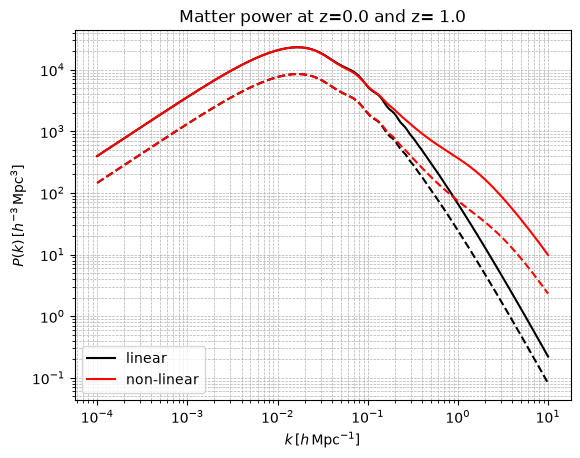

In [15]:

for i, (redshift, line) in enumerate(zip(z, ["-", "--"])):
    plt.loglog(kh, pk[i, :], color="k", ls=line)
    plt.loglog(kh_nonlin, pk_nonlin[i, :], color="r", ls=line)
plt.legend(["linear", "non-linear"], loc="lower left")
plt.title("Matter power at z={} and z= {}".format(*tuple(z)));

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')

## 4.2 BONUS Impact of Baryon


All of the above was just considering dark matter. But baryon physics is complex. On the smallest scales, the gas will be heated by AGN (actvie galactic nuclei), and ejected out of the gravitational potential wells. To predict it is very complex, as one needs to rely on hydrodynamical simulations, ie. simulate both teh DM, and te baryons, with a complex phyiscs of the gas and star formation that is hard to model on a large range of scales. This is a very active field of research.
In CAMB, the HMCode_2020 module provides a one parameter fit of the matter power spectrum with impact of baryons, using the temperature of AGN as a parameter. 


#### 🧩 Using the HMCode_2020 module of CAMB, plot the matter power spectrum with different values of the AGN temperature.

You can sample from HMCode_logT_AGN = 7.6 to HMCode_logT_AGN = 8.7.
This can be done with the command 

`` pars.NonLinearModel.set_params(halofit_version='mead2020_feedback', HMCode_logT_AGN=logT)``

Plot the ratio with respect to the non linear power spectrum without feedback to better see the impact. 



In [16]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)


redshifts = [0]
kmax = 50 # 1/Mpc
maxkh = 20 # h/Mpc

#Gravity only power spectrum
pars.set_matter_power(redshifts=redshifts, kmax=50)
pars.NonLinear = camb.model.NonLinear_both
res_grav = camb.get_results(pars)
kh_grav, _, pk_grav = res_grav.get_matter_power_spectrum(minkh=1e-3, maxkh=20,
                                                  npoints=400)



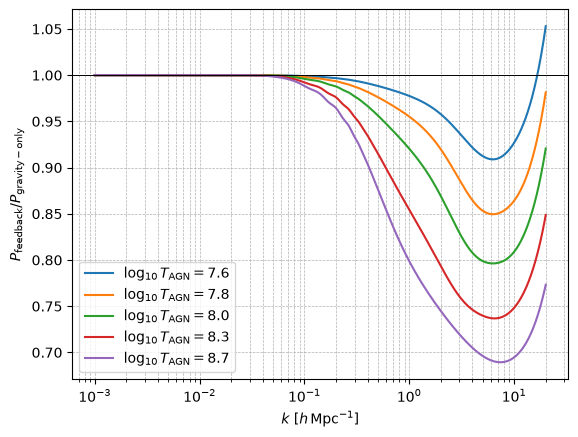

In [17]:
# Values of AGN temperature to sample
logT_values = [7.6, 7.8, 8.0, 8.3, 8.7]

fig, ax = plt.subplots()
for logT in logT_values:
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
    pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
    pars.set_matter_power(redshifts=redshifts, kmax=50)
    pars.NonLinear = camb.model.NonLinear_pk
    pars.NonLinearModel.set_params(halofit_version='mead2020_feedback',
                                   HMCode_logT_AGN=logT)
    res = camb.get_results(pars)
    kh, _, pk_fb = res.get_matter_power_spectrum(minkh=1e-3, maxkh=20,
                                                npoints=400)
    ax.semilogx(kh, pk_fb[0]/pk_grav[0], label=rf'$\log_{{10}}T_{{\rm AGN}} = {logT}$')

ax.axhline(1, c='k', lw=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\rm feedback}/P_{\rm gravity-only}$')
ax.legend(); ax.grid(True, which='both', ls='--', lw=0.5)

#### What you should see 

You get the characteristic **"baryonic spoon"**: flat at 1 on large scales, a suppression trough centred near $k \sim 5$–10 h/Mpc that deepens with $\log T_{\rm AGN}$, then recovery at higher $k$.

The fiducial value is $\log_{10} T_{\rm AGN} = 7.8$, with roughly 7.6–8.3 spanning the range of current hydrodynamic simulations (BAHAMAS, and calibrated against the wider simulation landscape). Note that this spread is *wider than the statistical precision* of upcoming surveys — baryonic feedback is currently one of the leading systematics for small-scale weak lensing, and marginalising over $\log T_{\rm AGN}$ is standard practice.

# 5. Mock matter density field 

We have learned above how to obtain a theoretical prediction for the matter power spectrum. 
Now we are going to simulate a matter overdensity field in a 3D box at redshitf $z=0$. 

The overdensity field at a position $\mathbf{x}$ is defined as 
$$ \delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \bar \rho}{\bar \rho}\, ,$$
where $\rho(\mathbf{x})$ is the density field and $\bar \rho$ is the average density in the Universe

The linear matter overdensity field is a centered and homogeneous GRF, so we have the following property
$$\langle\tilde\delta(\mathbf{k})\tilde\delta^*(\mathbf{k}')\rangle = (2\pi)^3 P(k)\,\delta_D(\mathbf{k}-\mathbf{k}')$$
where $P(k)$ is the matter power spectrum. 



Remember that the FFT from numpy ignores the sampling interval, and to compare to a physical (continuous) prediction, we need to multiply the numpy FFT by this sampling interval. Here we are in 3D so the sampling intverval becomes the volume of the voxels. 
The Fourier coefficient of our field are thus related to the numpy Fourier coefficients $\delta_\mathbf{n}$ by 
$\tilde \delta(\mathbf{k}) = \tilde \delta_\mathbf{n} V_{\rm cell}$
with $V_{\rm cell}$ the volume of one voxel. 



The standard recipe is to first generate a white noise GRF $w(x) \sim \mathcal{N}(0, 1)$, pass in Fourier space, and then **colour** it, so it has the expected power spectrum.  
Indeed, we have $\left<w(\mathbf{x}) w(\mathbf{x'})\right> = \delta_D(\mathbf{x} - \mathbf{x'})$, so the power spectrum of $w$ is $P_w(k) = 1$.

Thus we can define $\tilde \delta(\mathbf{k}) \equiv \tilde w(\mathbf{k})  \sqrt{P(k)}$, which will have the expected power spectrum. 

Since the density field $\delta(x)$ is real, in Fourier space we have $\tilde \delta(\mathbf{k}) = \tilde  \delta(-\mathbf{k})$. This allows us to save memory space as we need to compute only half of the Fouier modes. This is managed by the numpy `rfftn` module, which computes only half of the coefficients. 

In [18]:
#Set up the CAMB linear power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
pars.set_matter_power(redshifts=[0], kmax=100.0)

#Linear spectra
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)

# The CAMB interpolator defined above allows us to get the value of P(k) for any k and z 
PK = camb.get_matter_power_interpolator(pars, nonlinear=False, kmax=1e2, var1='delta_tot',zmin=0.0, zmax=10.0)
zout = 0 


In [19]:
N = 128 # Number of pixels on each axis
Lbox = 1000.  # define the box size in Mpc/h
k0   = 2*np.pi / Lbox # the fundamental mode 

kk = np.fft.fftfreq(N) * k0 * N
ks = np.fft.rfftfreq(N) * k0 * N
kvec = np.array(np.meshgrid(kk,kk,ks))
kmod = np.sqrt(np.sum(kvec**2,axis=0))
kny = k0 * N/2

pixel_vol = Lbox**3 / N**3  # in Mpc**3


In [20]:
# colour white noise; rfftn/irfftn enforce Hermitian symmetry for free
white = np.random.normal(size=(N, N, N))
delta_k = np.fft.rfftn(white)

delta_k *= np.sqrt(PK.P(zout,kmod) / pixel_vol)
delta_k[0, 0, 0] = 0.0            # zero mean

delta = np.fft.irfftn(delta_k)

/opt/homebrew/Caskroom/miniforge/base/envs/cosmoschool/lib/python3.14/site-packages/camb/results.py:1105: RuntimeWarning: divide by zero encountered in log
  return self.logsign * np.exp(self(z, np.log(kh), grid=grid))


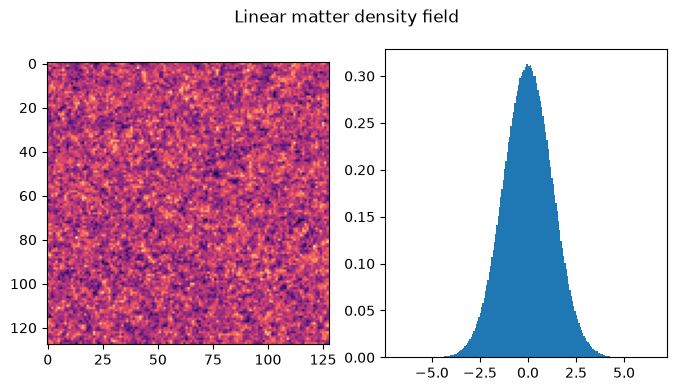

In [21]:
fig, ax = plt.subplots(1,2,figsize=(8,4))
fig.suptitle('Linear matter density field')
ax[0].imshow(delta[...,N//2], cmap='magma')
ax[1].hist(delta.flatten(),bins=200,density=True);


(<Figure size 800x700 with 2 Axes>,
 <Axes3D: xlabel='x [Mpc/h]', ylabel='y [Mpc/h]', zlabel='z [Mpc/h]'>)

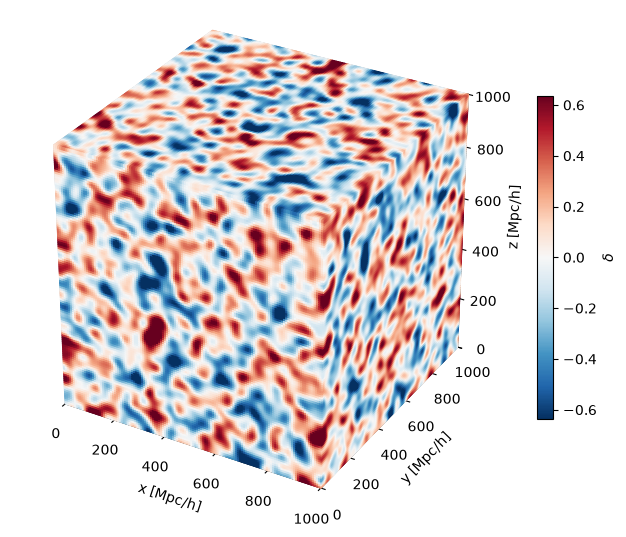

In [22]:
def plot_cube_faces(delta, L, smooth_cells=2, cmap='RdBu_r'):
    """Three orthogonal slices drawn on the faces of a cube."""
    from scipy.ndimage import gaussian_filter
    N = delta.shape[0]
    d = gaussian_filter(delta, smooth_cells) if smooth_cells else delta

    # symmetric colour scale, clipped so a few outliers don't wash it out
    v = np.percentile(np.abs(d), 99)
    norm = colors.Normalize(-v, v)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    x = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, x, indexing='ij')
    Z0, Z1 = np.zeros_like(X), np.full_like(X, L)

    # z = L face (top): slice at k = N-1
    ax.plot_surface(X, Y, Z1, facecolors=sm.to_rgba(d[:, :, -1]),
                    shade=False, rstride=1, cstride=1)
    # y = 0 face: slice at j = 0
    ax.plot_surface(X, Z0, Y, facecolors=sm.to_rgba(d[:, 0, :]),
                    shade=False, rstride=1, cstride=1)
    # x = 0 face: slice at i = 0
    ax.plot_surface(Z1, X, Y, facecolors=sm.to_rgba(d[-1, :, :]),
                    shade=False, rstride=1, cstride=1)

    ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_zlim(0, L)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel('x [Mpc/h]'); ax.set_ylabel('y [Mpc/h]'); ax.set_zlabel('z [Mpc/h]')
    fig.colorbar(sm, ax=ax, shrink=0.6, label=r'$\delta$')
    return fig, ax

plot_cube_faces(delta, L=Lbox)

In [23]:
def measure_pk(delta, L, nbins=25, kmin=None, kmax=None):
    """Shell-averaged P(k) from a real field. Returns k, P, Nmodes."""
    N = delta.shape[0]
    V_cell, V = (L/N)**3, L**3

    dk = np.fft.rfftn(delta)
    P = np.abs(dk)**2 * V_cell**2 / V          # inverting Step 2

    kf = 2*np.pi*np.fft.fftfreq(N, d=L/N)
    kz = 2*np.pi*np.fft.rfftfreq(N, d=L/N)
    kx, ky, kz = np.meshgrid(kf, kf, kz, indexing='ij')
    k = np.sqrt(kx**2 + ky**2 + kz**2)

    # weight: interior modes stored once represent +/-k, k_z=0 and Nyquist
    # planes represent one mode each
    w = np.full(k.shape, 2.0)
    w[:, :, 0] = 1.0
    if N % 2 == 0:
        w[:, :, -1] = 1.0

    kmin = kmin or 2*np.pi/L
    kmax = kmax or np.pi*N/L
    bins = np.logspace(np.log10(kmin), np.log10(kmax), nbins+1)

    idx = np.digitize(k.ravel(), bins)
    kr, Pr, wr = k.ravel(), P.ravel(), w.ravel()
    sel = (idx > 0) & (idx <= nbins)

    Nm = np.bincount(idx[sel], weights=wr[sel], minlength=nbins+2)[1:nbins+1]
    ks = np.bincount(idx[sel], weights=(wr*kr)[sel], minlength=nbins+2)[1:nbins+1]
    Ps = np.bincount(idx[sel], weights=(wr*Pr)[sel], minlength=nbins+2)[1:nbins+1]

    good = Nm > 0
    return ks[good]/Nm[good], Ps[good]/Nm[good], Nm[good]


km, Pm, Nm = measure_pk(delta, Lbox)
err = Pm * np.sqrt(2./Nm)

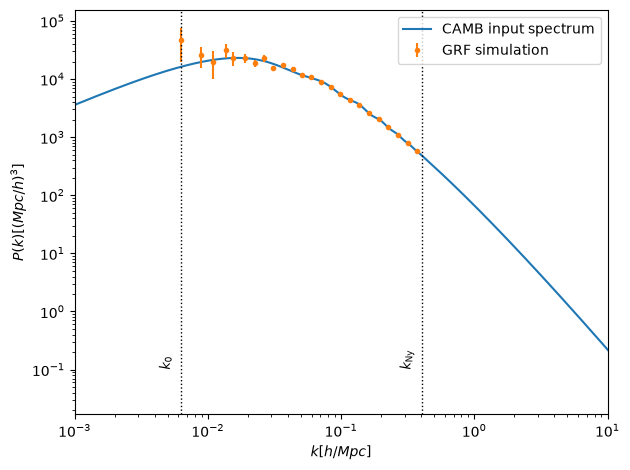

In [24]:
plt.loglog(kh, PK.P(zout, kh), label='CAMB input spectrum')

plt.errorbar(km, Pm, yerr=err, fmt='.', color='tab:orange',
             label='GRF simulation')
for kv, lbl in [(2*np.pi/Lbox, r'$k_0$'), (kny, r'$k_{\rm Ny}$')]:
    
    plt.axvline(kv, c='k', ls=':', lw=1)
    
    plt.text(kv*0.7, 1e-1, lbl, rotation=90, va='bottom', fontsize=9)


plt.xlim(1e-3, 10)
plt.xlabel(r'$k[h/Mpc]$') 
plt.ylabel(r'$P(k)[(Mpc/h)^3]$')
plt.legend()
plt.tight_layout()

## Bonus: Zeldovich approximation 

To perform a full N-body simulation would be expensive. We can however do a simpler approximation for the evolution of the matter density field iwth time. This is called the Zeldovi'ch approximation. At leading order, the particles are moving on strait lines, driven by the gradient of the gravitaional potential. 
You should see below the displacement of particules under the effect of gravity. The caracteristic shape is called the cosmic web, and this is how the distribution of matter looks like on very large scales in the Universe. 

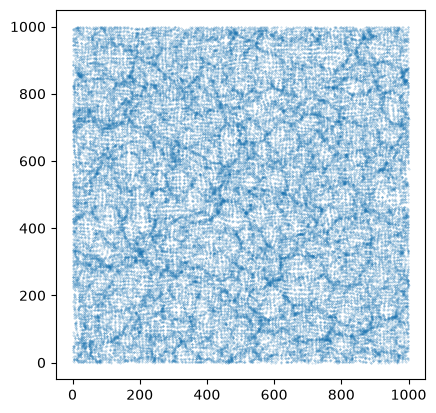

In [25]:
# set up unperturbed particle mesh
qq = np.linspace(0,Lbox,N,endpoint=False)
xvec = np.array(np.meshgrid(qq,qq,qq))

# use Zeldovich to move particles
for i in range(3):
    psi_i = np.zeros_like(kmod,dtype=complex)
    mask = kmod > 0.0
    psi_i[mask] = -1j*kvec[i,mask]/kmod[mask]**2 * delta_k[mask]
    xvec[i,...] += 1.0 *np.fft.irfftn( psi_i ) 

fig, ax = plt.subplots()
# plot particles with q-space z-coordinate in some range:
i0 = 0
i1 = 4
ax.scatter(np.fmod(Lbox+xvec[0,:,:,i0:i1],Lbox),np.fmod(Lbox+xvec[1,:,:,i0:i1],Lbox),s=0.1,alpha=0.4)
ax.set_aspect(1.0)

